# Experimentos de Modelado

Proyecto: **IA para salud animal** (predicción de enfermedades dermatológicas en perros a partir de datos clínicos e imágenes).

Este notebook implementa los experimentos definidos en el informe para:
- Dataset tabular clínico (modelos clásicos de clasificación).
- Dataset de imágenes dermatológicas (CNN con *transfer learning*).

## 1. Configuración general

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import EfficientNetB0

from collections import Counter
import pathlib

print('Versión de TensorFlow:', tf.__version__)

ruta_base_datasets = os.path.join('..', 'datasets')
print('Ruta base de datasets:', os.path.abspath(ruta_base_datasets))

Versión de TensorFlow: 2.17.0
Ruta base de datasets: c:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets


## 2. Experimentos con dataset tabular clínico

En esta parte se trabaja con los CSV ya preprocesados (`clinical_features_train/valid/test.csv`).

Objetivos:
- Entrenar y comparar dos modelos:
  - Regresión Logística (baseline lineal e interpretable).
  - Random Forest (modelo no lineal para capturar interacciones).
- Manejar el desbalance de clases (~80/20) con `class_weight='balanced'`.
- Evaluar con métricas robustas al desbalance: F1 macro y balanced accuracy.
- Analizar interpretabilidad básica: coeficientes (LogReg) e importancia de variables (RF).

### 2.1 Carga de datos tabulares

In [2]:
ruta_train_clinico = os.path.join(ruta_base_datasets, 'clinical_features_train.csv')
ruta_valid_clinico = os.path.join(ruta_base_datasets, 'clinical_features_valid.csv')
ruta_test_clinico  = os.path.join(ruta_base_datasets, 'clinical_features_test.csv')

df_train = pd.read_csv(ruta_train_clinico)
df_valid = pd.read_csv(ruta_valid_clinico)
df_test  = pd.read_csv(ruta_test_clinico)

print('Tamaño train:', df_train.shape)
print('Tamaño valid:', df_valid.shape)
print('Tamaño test :', df_test.shape)

df_train.head()

Tamaño train: (3509, 73)
Tamaño valid: (752, 73)
Tamaño test : (752, 73)


,Age,Weight_kg,target_derm,age_squared,weight_zscore_by_breed,age_weight_interaction,breed_is_other,is_vaccinated,has_parasite_history,has_chronic_illness,...,breed_grouped_german shepherd,breed_grouped_golden retriever,breed_grouped_labrador retriever,breed_grouped_mixed breed,breed_grouped_poodle,breed_grouped_rottweiler,breed_grouped_yorkshire terrier,age_bucket_puppy,age_bucket_adult,age_bucket_senior
0,5.8,22.9,1,33.64,-1.787272,132.82,0,0,0,0,...,False,False,False,False,False,True,False,False,True,False
1,9.4,3.8,1,88.36,-1.174947,35.72,0,1,0,0,...,False,False,False,False,True,False,False,False,False,True
2,1.8,4.4,1,3.24,-0.930756,7.92,0,0,0,0,...,False,False,False,False,False,False,True,False,True,False
3,8.2,4.4,1,67.24,-0.930756,36.08,0,0,0,0,...,False,False,False,False,False,False,True,False,False,True
4,14.6,8.0,0,213.16,0.919236,116.80,0,0,0,0,...,False,False,False,False,False,False,True,False,False,True


### 2.2 Distribución de la variable objetivo

In [3]:
columna_objetivo = 'target_derm'

for nombre, df in [('train', df_train), ('valid', df_valid), ('test', df_test)]:
    distribucion = df[columna_objetivo].value_counts(normalize=True).sort_index()
    print(f"\nDistribución objetivo ({nombre}):")
    print(distribucion)
    print('Proporciones (%)')
    print((distribucion * 100).round(2))


Distribución objetivo (train):
target_derm
0    0.796523
1    0.203477
Name: proportion, dtype: float64
Proporciones (%)
target_derm
0    79.65
1    20.35
Name: proportion, dtype: float64

Distribución objetivo (valid):
target_derm
0    0.796543
1    0.203457
Name: proportion, dtype: float64
Proporciones (%)
target_derm
0    79.65
1    20.35
Name: proportion, dtype: float64

Distribución objetivo (test):
target_derm
0    0.796543
1    0.203457
Name: proportion, dtype: float64
Proporciones (%)
target_derm
0    79.65
1    20.35
Name: proportion, dtype: float64


### 2.3 Preparación de features y objetivo

In [4]:
columnas_features = [c for c in df_train.columns if c != columna_objetivo]

X_train = df_train[columnas_features].values
y_train = df_train[columna_objetivo].values

X_valid = df_valid[columnas_features].values
y_valid = df_valid[columna_objetivo].values

X_test = df_test[columnas_features].values
y_test = df_test[columna_objetivo].values

len(columnas_features), columnas_features[:10]

(72,
 ['Age',
  'Weight_kg',
  'age_squared',
  'weight_zscore_by_breed',
  'age_weight_interaction',
  'breed_is_other',
  'is_vaccinated',
  'has_parasite_history',
  'has_chronic_illness',
  'has_allergies'])

### 2.4 Funciones auxiliares de evaluación

In [5]:
def evaluar_en_split(modelo, X, y, nombre_split='valid'):
    y_pred = modelo.predict(X)
    acc = accuracy_score(y, y_pred)
    bacc = balanced_accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')
    print(f"\nResultados en {nombre_split}:")
    print(f"Accuracy:           {acc:.4f}")
    print(f"Balanced accuracy:  {bacc:.4f}")
    print(f"F1 macro:           {f1:.4f}")
    print("\nReporte de clasificación:")
    print(classification_report(y, y_pred, digits=4))
    print("\nMatriz de confusión:")
    print(confusion_matrix(y, y_pred))
    return {'accuracy': acc, 'balanced_accuracy': bacc, 'f1_macro': f1}

def graficar_importancias(features, importancias, top_n=15, titulo='Importancia de variables'):
    idx = np.argsort(importancias)[-top_n:]
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(idx)), importancias[idx])
    plt.yticks(range(len(idx)), [features[i] for i in idx])
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

### 2.5 Entrenamiento: Regresión Logística

In [6]:
pipe_logreg = Pipeline([
    ('escalador', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe_logreg.fit(X_train, y_train)
resultados_logreg_valid = evaluar_en_split(pipe_logreg, X_valid, y_valid, nombre_split='valid (LogReg)')


Resultados en valid (LogReg):
Accuracy:           0.9840
Balanced accuracy:  0.9681
F1 macro:           0.9750

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9851    0.9950    0.9900       599
           1     0.9796    0.9412    0.9600       153

    accuracy                         0.9840       752
   macro avg     0.9824    0.9681    0.9750       752
weighted avg     0.9840    0.9840    0.9839       752


Matriz de confusión:
[[596   3]
 [  9 144]]


### 2.6 Entrenamiento: Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
resultados_rf_valid = evaluar_en_split(rf, X_valid, y_valid, nombre_split='valid (Random Forest)')


Resultados en valid (Random Forest):
Accuracy:           0.9867
Balanced accuracy:  0.9673
F1 macro:           0.9790

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9836    1.0000    0.9917       599
           1     1.0000    0.9346    0.9662       153

    accuracy                         0.9867       752
   macro avg     0.9918    0.9673    0.9790       752
weighted avg     0.9869    0.9867    0.9865       752


Matriz de confusión:
[[599   0]
 [ 10 143]]


### 2.7 Comparación y selección de mejor modelo (tabular)

In [8]:
resultados_tabular = pd.DataFrame([
    {'modelo': 'LogisticRegression', **resultados_logreg_valid},
    {'modelo': 'RandomForest', **resultados_rf_valid}
])

resultados_tabular

,modelo,accuracy,balanced_accuracy,f1_macro
0,LogisticRegression,0.984043,0.968084,0.975017
1,RandomForest,0.986702,0.967320,0.978969


In [9]:
mejor_fila = resultados_tabular.sort_values('f1_macro', ascending=False).iloc[0]
modelo_ganador_nombre = mejor_fila['modelo']
print('Mejor modelo según F1 macro en validación:', modelo_ganador_nombre)

if modelo_ganador_nombre == 'LogisticRegression':
    modelo_ganador = pipe_logreg
else:
    modelo_ganador = rf

Mejor modelo según F1 macro en validación: RandomForest


### 2.8 Reentrenamiento en train+valid y evaluación en test

In [10]:
X_train_full = np.vstack([X_train, X_valid])
y_train_full = np.concatenate([y_train, y_valid])

if modelo_ganador_nombre == 'LogisticRegression':
    modelo_final = Pipeline([
        ('escalador', StandardScaler()),
        ('modelo', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
else:
    modelo_final = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

modelo_final.fit(X_train_full, y_train_full)
resultados_test_tabular = evaluar_en_split(modelo_final, X_test, y_test, nombre_split='test (modelo final tabular)')
resultados_test_tabular


Resultados en test (modelo final tabular):
Accuracy:           0.9827
Balanced accuracy:  0.9575
F1 macro:           0.9724

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9788    1.0000    0.9893       599
           1     1.0000    0.9150    0.9556       153

    accuracy                         0.9827       752
   macro avg     0.9894    0.9575    0.9724       752
weighted avg     0.9831    0.9827    0.9824       752


Matriz de confusión:
[[599   0]
 [ 13 140]]


{'accuracy': 0.9827127659574468,
 'balanced_accuracy': 0.957516339869281,
 'f1_macro': 0.9724482347536659}

### 2.9 Interpretabilidad básica de los modelos tabulares

In [11]:
# Interpretabilidad Regresión Logística (si se entrenó)
coeficientes_logreg = None
if pipe_logreg is not None:
    modelo_lr = pipe_logreg.named_steps['modelo']
    coeficientes_logreg = modelo_lr.coef_[0]
    top_idx = np.argsort(coeficientes_logreg)
    print('Top 10 coeficientes negativos (asociados a clase 0):')
    for i in top_idx[:10]:
        print(columnas_features[i], coeficientes_logreg[i])
    print('\nTop 10 coeficientes positivos (asociados a clase 1):')
    for i in top_idx[-10:]:
        print(columnas_features[i], coeficientes_logreg[i])

Top 10 coeficientes negativos (asociados a clase 0):
respiratory_symptoms_count -1.2848045447475294
systemic_symptoms_count -0.8962696147035732
gi_symptoms_count -0.733598032286203
has_depression -0.7235998710934237
fever_and_diarrhea -0.6648062047381951
has_kidney_history -0.5929308630173167
has_pains -0.5885633138777631
has_allergies -0.5846833219330309
has_lameness -0.5622287097548806
has_chronic_illness -0.54368325664015

Top 10 coeficientes positivos (asociados a clase 1):
has_death 0.3962089420325082
breed_grouped_yorkshire terrier 0.4427874471489106
has_loss_of_appetite 0.45405934450500735
has_sneezing 0.5411249231366662
breed_grouped_poodle 0.554091984324319
has_coughing 0.5710215337378887
chronic_conditions_count 0.7292623209432539
Weight_kg 1.353566473799867
has_skin_history 3.260184661377282
dermatological_symptoms_count 4.395717975612614


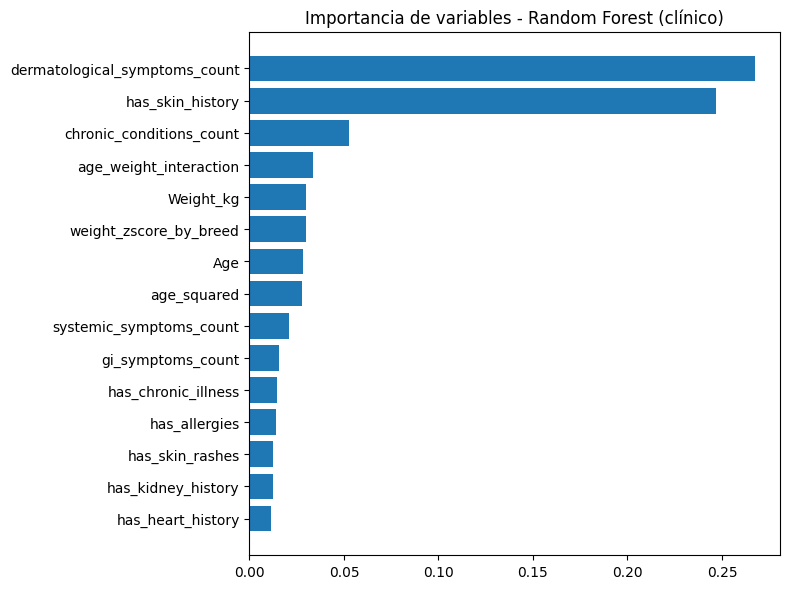

In [12]:
# Importancia de variables en Random Forest
importancias_rf = rf.feature_importances_
graficar_importancias(columnas_features, importancias_rf, top_n=15, titulo='Importancia de variables - Random Forest (clínico)')

## 3. Experimentos con dataset de imágenes dermatológicas

En esta parte se trabaja con las imágenes organizadas en subcarpetas por clase dentro de `train/`, `valid/` y `test/`.

Objetivos:
- Entrenar una CNN con *transfer learning* basada en **EfficientNetB0**.
- Manejar el desbalance entre clases mediante pesos de clase en la función de pérdida.
- Evaluar el desempeño con métricas por clase y matriz de confusión.
- Aplicar Grad-CAM sobre ejemplos representativos para analizar qué regiones de la piel usa el modelo.

### 3.1 Carga de datos de imagen

In [13]:
ruta_train_img = os.path.join(ruta_base_datasets, 'train')
ruta_valid_img = os.path.join(ruta_base_datasets, 'valid')
ruta_test_img  = os.path.join(ruta_base_datasets, 'test')

tamaño_imagen = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    ruta_train_img,
    image_size=tamaño_imagen,
    batch_size=batch_size,
    label_mode='int'
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    ruta_valid_img,
    image_size=tamaño_imagen,
    batch_size=batch_size,
    label_mode='int'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    ruta_test_img,
    image_size=tamaño_imagen,
    batch_size=batch_size,
    label_mode='int',
    shuffle=False
)

clases = train_ds.class_names
num_clases = len(clases)
print('Clases:', clases)
print('Número de clases:', num_clases)

Found 3022 files belonging to 6 classes.
Found 860 files belonging to 6 classes.
Found 433 files belonging to 6 classes.
Clases: ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
Número de clases: 6


### 3.2 Optimización mínima del pipeline de datos

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

### 3.3 Cálculo de pesos de clase para el desbalance

In [15]:
ruta_train_path = pathlib.Path(ruta_train_img)
conteo_clases = {}
for carpeta in ruta_train_path.iterdir():
    if carpeta.is_dir():
        num_imagenes = len(list(carpeta.glob('*.jpg'))) + len(list(carpeta.glob('*.jpeg'))) + len(list(carpeta.glob('*.png')))
        conteo_clases[carpeta.name] = num_imagenes

print('Conteo de imágenes por clase (train):', conteo_clases)

total_imagenes = sum(conteo_clases.values())
pesos_clase = {}
for idx, nombre_clase in enumerate(clases):
    n_i = conteo_clases.get(nombre_clase, 1)
    pesos_clase[idx] = total_imagenes / (num_clases * n_i)

print('Pesos de clase:', pesos_clase)

Conteo de imágenes por clase (train): {'demodicosis': 588, 'Dermatitis': 546, 'Fungal_infections': 375, 'Healthy': 492, 'Hypersensitivity': 230, 'ringworm': 791}
Pesos de clase: {0: 0.9224664224664225, 1: 1.3431111111111111, 2: 1.0237127371273713, 3: 2.189855072463768, 4: 0.8565759637188208, 5: 0.6367467340918669}


### 3.4 Definición del modelo EfficientNetB0 con transfer learning

In [16]:
entrada = layers.Input(shape=tamaño_imagen + (3,))

capa_aumento = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
], name='aumento_datos')

x = capa_aumento(entrada)
x = layers.Rescaling(1./255)(x)

base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=tamaño_imagen + (3,))
base_model.trainable = False

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
salida = layers.Dense(num_clases, activation='softmax')(x)

modelo_cnn = models.Model(entrada, salida)

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_cnn.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aumento_datos (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### 3.5 Entrenamiento de la CNN

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
]

historial = modelo_cnn.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 363ms/step - accuracy: 0.2472 - loss: 1.7555 - val_accuracy: 0.2023 - val_loss: 1.7420
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 35s 360ms/step - accuracy: 0.2303 - loss: 1.7568 - val_accuracy: 0.2465 - val_loss: 1.7399
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 34s 356ms/step - accuracy: 0.2242 - loss: 1.7627 - val_accuracy: 0.2465 - val_loss: 1.7514
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 36s 378ms/step - accuracy: 0.2521 - loss: 1.7458 - val_accuracy: 0.2023 - val_loss: 1.7605
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 36s 372ms/step - accuracy: 0.2383 - loss: 1.7520 - val_accuracy: 0.2035 - val_loss: 1.7462
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 34s 357ms/step - accuracy: 0.2377 - loss: 1.7514 - val_accuracy: 0.2465 - val_loss: 1.7362
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 36s 376ms/step - accuracy: 0.2331 - loss: 1.7480 - val_accuracy: 0.2465 - val_loss: 1.7462
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 34s 356ms/step - accuracy: 0.2664 - loss: 1.7266 - val_accu

In [22]:
# Descongelar parcialmente la EfficientNet (últimas capas)
base_model.trainable = True

for capa in base_model.layers[:-20]:
    capa.trainable = False

modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_loss'
    )
]

historial_ft = modelo_cnn.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=10,
    callbacks=callbacks_ft
)


Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 49s 445ms/step - accuracy: 0.2293 - loss: 1.7787 - val_accuracy: 0.2465 - val_loss: 1.7601
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 419ms/step - accuracy: 0.2535 - loss: 1.7408 - val_accuracy: 0.2465 - val_loss: 1.7873
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 433ms/step - accuracy: 0.2493 - loss: 1.7376 - val_accuracy: 0.2465 - val_loss: 1.7709
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 396ms/step - accuracy: 0.2626 - loss: 1.7334 - val_accuracy: 0.2465 - val_loss: 1.7472
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step - accuracy: 0.2515 - loss: 1.7370 - val_accuracy: 0.2465 - val_loss: 1.7368
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 400ms/step - accuracy: 0.2619 - loss: 1.7436 - val_accuracy: 0.2465 - val_loss: 1.7340
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 419ms/step - accuracy: 0.2661 - loss: 1.7388 - val_accuracy: 0.2465 - val_loss: 1.7329
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 401ms/step - accuracy: 0.2494 - loss: 1.7423 - val_accu

### 3.6 Curvas de entrenamiento y validación

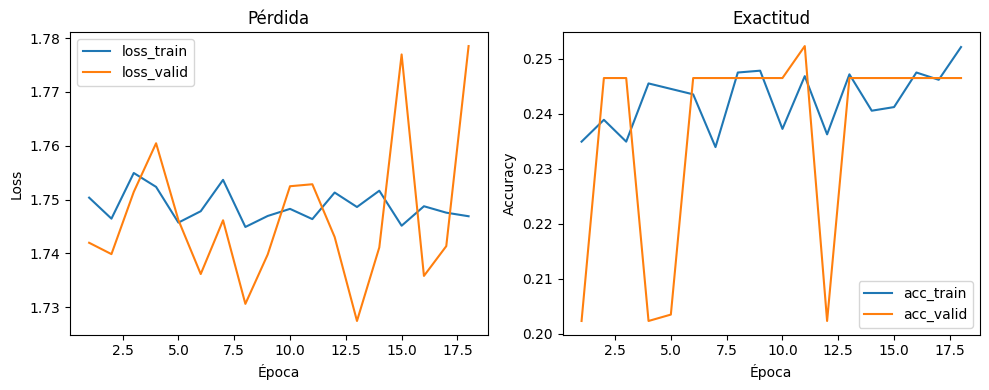

In [23]:
def graficar_historial(historial):
    historia = historial.history
    epocas = range(1, len(historia['loss']) + 1)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epocas, historia['loss'], label='loss_train')
    plt.plot(epocas, historia['val_loss'], label='loss_valid')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Pérdida')

    plt.subplot(1, 2, 2)
    plt.plot(epocas, historia['accuracy'], label='acc_train')
    plt.plot(epocas, historia['val_accuracy'], label='acc_valid')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Exactitud')

    plt.tight_layout()
    plt.show()

graficar_historial(historial)

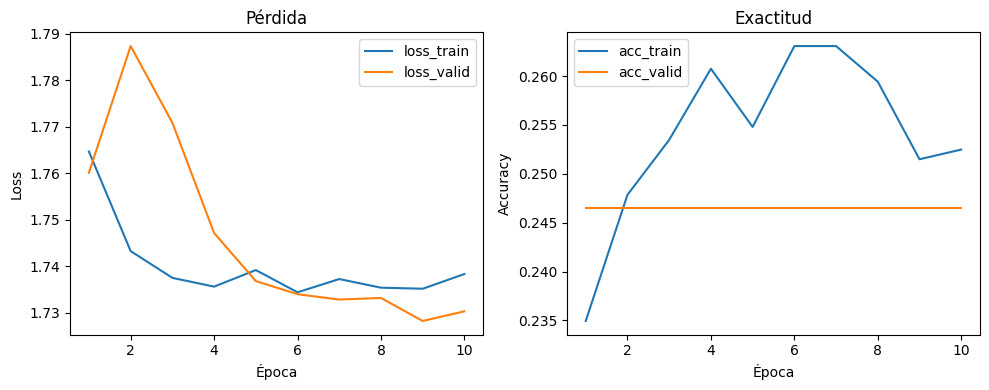

In [24]:
graficar_historial(historial_ft)

### 3.7 Evaluación en el conjunto de prueba (imágenes)

In [25]:
loss_test, acc_test = modelo_cnn.evaluate(test_ds)
print(f'Loss en test: {loss_test:.4f}')
print(f'Accuracy en test: {acc_test:.4f}')

y_pred_prob = modelo_cnn.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = []
for _, etiquetas in test_ds:
    y_true.extend(etiquetas.numpy())
y_true = np.array(y_true)

print('\nReporte de clasificación (imágenes):')
print(classification_report(y_true, y_pred, target_names=clases, digits=4))

print('\nMatriz de confusión (imágenes):')
print(confusion_matrix(y_true, y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - accuracy: 0.0694 - loss: 1.8539
Loss en test: 1.7125
Accuracy en test: 0.2656
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step

Reporte de clasificación (imágenes):
                   precision    recall  f1-score   support

       Dermatitis     0.0000    0.0000    0.0000        66
Fungal_infections     0.0000    0.0000    0.0000        54
          Healthy     0.0000    0.0000    0.0000        69
 Hypersensitivity     0.0000    0.0000    0.0000        29
      demodicosis     0.0000    0.0000    0.0000       100
         ringworm     0.2656    1.0000    0.4197       115

         accuracy                         0.2656       433
        macro avg     0.0443    0.1667    0.0700       433
     weighted avg     0.0705    0.2656    0.1115       433


Matriz de confusión (imágenes):
[[  0   0   0   0   0  66]
 [  0   0   0   0   0  54]
 [  0   0   0   0   0  69]
 [  0   0   0   0   0  29]
 [  0   0   0   0   0 100]
 [  0   0   0   0   0 115]]


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

### 3.8 Mapas de salencia para análisis cualitativo

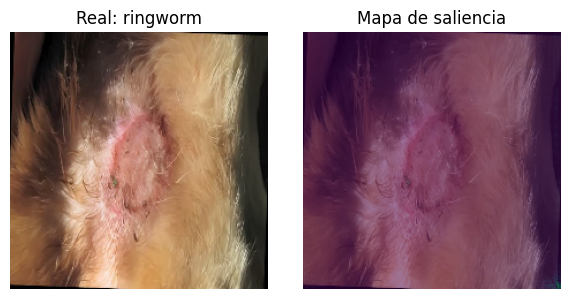

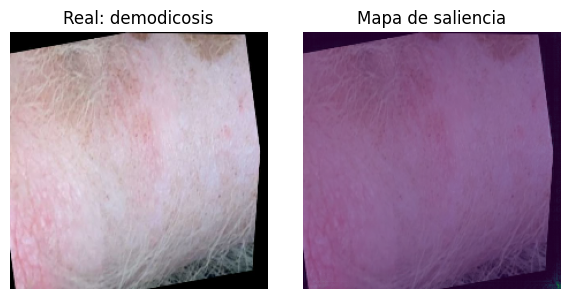

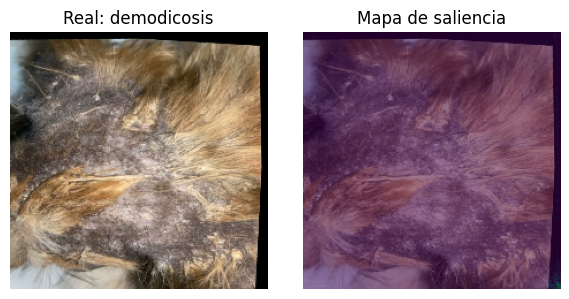

In [28]:
def generar_mapa_saliencia(modelo, imagen_array, indice_clase=None):
    # Asegurar batch de tamaño 1 y tipo float32
    if imagen_array.ndim == 3:
        imagen_array = np.expand_dims(imagen_array, axis=0)

    # Mismo escalado que en entrenamiento (modelo ya tiene Rescaling(1./255))
    imagen = tf.convert_to_tensor(imagen_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(imagen)
        # Desactivamos data augmentation usando training=False
        predicciones = modelo(imagen, training=False)
        if indice_clase is None:
            indice_clase = tf.argmax(predicciones[0])
        salida_clase = predicciones[:, indice_clase]

    # Gradiente de la clase respecto al input
    grads = tape.gradient(salida_clase, imagen)[0]  # (H, W, 3)

    # Tomar máximo por canal y normalizar
    saliencia = tf.reduce_max(tf.abs(grads), axis=-1)
    saliencia /= (tf.reduce_max(saliencia) + 1e-8)
    return saliencia.numpy()

def mostrar_mapa_saliencia(modelo, dataset, num_ejemplos=3):
    import random
    lista_imagenes, lista_etiquetas = [], []
    for imagenes, etiquetas in dataset:
        for img, lab in zip(imagenes, etiquetas):
            lista_imagenes.append(img.numpy())
            lista_etiquetas.append(lab.numpy())

    indices = random.sample(range(len(lista_imagenes)),
                            k=min(num_ejemplos, len(lista_imagenes)))

    for idx in indices:
        img = lista_imagenes[idx]
        etiqueta = lista_etiquetas[idx]
        saliencia = generar_mapa_saliencia(modelo, img)

        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img.astype('uint8'))
        plt.axis('off')
        plt.title(f'Real: {clases[etiqueta]}')

        plt.subplot(1, 2, 2)
        plt.imshow(img.astype('uint8'))
        plt.imshow(saliencia, alpha=0.5)
        plt.axis('off')
        plt.title('Mapa de saliencia')
        plt.tight_layout()
        plt.show()

mostrar_mapa_saliencia(modelo_cnn, test_ds, num_ejemplos=3)
